# Topic 3 - Decision Trees & k-NN

In [5]:
import collections
from io import StringIO

import numpy as np
import pandas as pd
import pydotplus  # pip install pydotplus
import seaborn as sns
from ipywidgets import Image
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)

In [6]:
# Create dataframe with dummy variables
def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis=1)
    out.drop(feature_list, axis=1, inplace=True)
    return out


# Some feature values are present in train and absent in test and vice-versa.
def intersect_features(train, test):
    common_feat = list(set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

In [7]:
features = ["Looks", "Alcoholic_beverage", "Eloquence", "Money_spent"]

In [8]:
df_train = {}
df_train["Looks"] = [
    "handsome",
    "handsome",
    "handsome",
    "repulsive",
    "repulsive",
    "repulsive",
    "handsome",
]
df_train["Alcoholic_beverage"] = ["yes", "yes", "no", "no", "yes", "yes", "yes"]
df_train["Eloquence"] = ["high", "low", "average", "average", "low", "high", "average"]
df_train["Money_spent"] = ["lots", "little", "lots", "little", "lots", "lots", "lots"]
df_train["Will_go"] = LabelEncoder().fit_transform(["+", "-", "+", "-", "-", "+", "+"])

df_train = create_df(df_train, features)
df_train

,Will_go,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Eloquence_low,Money_spent_little,Money_spent_lots
0,0,True,False,False,True,False,True,False,False,True
1,1,True,False,False,True,False,False,True,True,False
2,0,True,False,True,False,True,False,False,False,True
3,1,False,True,True,False,True,False,False,True,False
4,1,False,True,False,True,False,False,True,False,True
5,0,False,True,False,True,False,True,False,False,True
6,0,True,False,False,True,True,False,False,False,True


In [9]:
df_test = {}
df_test["Looks"] = ["handsome", "handsome", "repulsive"]
df_test["Alcoholic_beverage"] = ["no", "yes", "yes"]
df_test["Eloquence"] = ["average", "high", "average"]
df_test["Money_spent"] = ["lots", "little", "lots"]
df_test = create_df(df_test, features)
df_test

,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Money_spent_little,Money_spent_lots
0,True,False,True,False,True,False,False,True
1,True,False,False,True,False,True,True,False
2,False,True,False,True,True,False,False,True


In [10]:
# Some feature values are present in train and absent in test and vice-versa.
y = df_train["Will_go"]
df_train, df_test = intersect_features(train=df_train, test=df_test)
df_train

,Money_spent_little,Money_spent_lots,Alcoholic_beverage_no,Eloquence_high,Looks_handsome,Alcoholic_beverage_yes,Looks_repulsive,Eloquence_average
0,False,True,False,True,True,True,False,False
1,True,False,False,False,True,True,False,False
2,False,True,True,False,True,False,False,True
3,True,False,True,False,False,False,True,True
4,False,True,False,False,False,True,True,False
5,False,True,False,True,False,True,True,False
6,False,True,False,False,True,True,False,True


In [11]:
df_test

,Money_spent_little,Money_spent_lots,Alcoholic_beverage_no,Eloquence_high,Looks_handsome,Alcoholic_beverage_yes,Looks_repulsive,Eloquence_average
0,False,True,True,False,True,False,False,True
1,True,False,False,True,True,True,False,False
2,False,True,False,False,False,True,True,True


---

## Part 1

1. What is the entropy $ S_0 $ of the initial system? By system states, we mean values of the binary feature “Will_go” - 0 or 1 - two states in total.

In [18]:
p = y.value_counts(normalize=True)
s_0 = - np.sum(p * np.log2(p))

s_0

np.float64(0.9852281360342515)

2. Let’s split the data by the feature “Looks_handsome”. What is the entropy $ S_1 $ of the left group - the one with “Looks_handsome”. What is the entropy $S_2$ in the opposite group? What is the information gain (IG) if we consider such a split?

In [16]:
from scipy.stats import entropy

In [24]:
p_handsome = df_train['Looks_handsome'].value_counts(normalize=True)
s_1 = entropy(y[df_train['Looks_handsome']].value_counts(), base=2)
s_2 = entropy(y[~ df_train['Looks_handsome']].value_counts(), base=2)

IG = s_0 - (
    (len(y[df_train['Looks_handsome']]) / len(y)) * s_1 +
    (len(y[~df_train['Looks_handsome']]) / len(y)) * s_2 
    )

s_0, s_1, s_2, IG

(np.float64(0.9852281360342515),
 np.float64(0.8112781244591328),
 np.float64(0.9182958340544894),
 np.float64(0.12808527889139443))

### Train a decision tree using sklearn on the training data. You may choose any depth for the tree

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

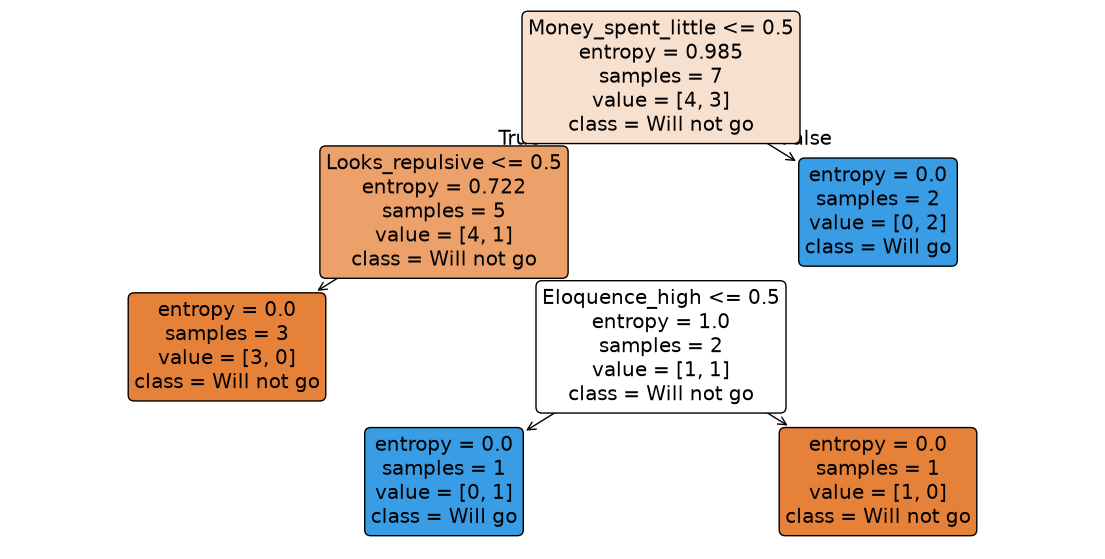

In [30]:
tree = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=17)
tree.fit(df_train, y)
predictions = tree.predict(df_test)

plt.figure(figsize=(14,7))
plot_tree(tree, feature_names=df_train.columns, class_names=['Will not go', 'Will go'], filled=True, rounded=True)
plt.show()

## Part 2